# SMA Variable Voltage Controller - Log Visualization

Plots data captured over the serial console from the firmware (`src/main.cpp`).

- **Cycle logs** - output of a `cycle` command. Columns:
  `t_ms, phase, target_v, wiper, vldo_v, isns_v, current_a, r_sma_ohm`
- **Calibration tables** - output of `cal` or `caldump`. Columns: `code, vldo_v`

### How to capture
Easiest: use the auto-recorder, which triggers a cycle and saves it for you:

```
python record_cycle.py --port COM4 --cycle 3.5 100 0.5 2000 5
```

It writes a timestamped file into `analysis/logs/`. Or capture manually:

```
pio device monitor -b 115200 | tee logs/run1.csv
```

Lines beginning with `#` (and the echoed command) are ignored by the loader below.


## Setup
Run this first. It auto-installs any missing packages into **this kernel** and is a fast no-op once they're present. If it installs anything, restart the kernel before continuing.

In [20]:
# Auto-install dependencies into the running kernel (sys.executable targets THIS env).
import importlib.util, subprocess, sys

REQUIRED = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib"}
missing = [pip_name for mod, pip_name in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed. If the imports below fail, restart the kernel and re-run.")
else:
    print("All dependencies present:", ", ".join(REQUIRED))


All dependencies present: pandas, numpy, matplotlib


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# Point these at your captured files. The cycle line auto-picks the newest
# cycle_*.csv in logs/ if you used record_cycle.py.
cyc = sorted(glob.glob("logs/cycle_*.csv"))
CYCLE_CSV = cyc[-1] if cyc else "logs/run1.csv"
CAL_CSV   = "logs/cal.csv"
print("Using cycle file:", CYCLE_CSV)

# Board constants (mirror include/config.h)
RSHUNT   = 0.33   # ohms
INA_GAIN = 10.0   # V/V (INA296A1)


Using cycle file: logs\cycle_20260610_162140.csv


## Loader
Reads a serial capture, skips `#` comments and any echoed command text, and locates the CSV header row.

In [22]:
def load_capture(path):
    """Load a serial capture, tolerating '#' comments and echoed command lines.
    The first line that looks like a CSV header (has commas + letters) wins."""
    rows, header = [], None
    with open(path, "r", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            if header is None:
                if "," in s and any(c.isalpha() for c in s):
                    header = [h.strip() for h in s.split(",")]
                continue
            parts = s.split(",")
            if len(parts) == len(header):     # skip stray/partial lines
                rows.append(parts)
    if header is None:
        raise ValueError(f"No CSV header found in {path}")
    df = pd.DataFrame(rows, columns=header)
    for c in df.columns:
        if c == "phase":
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")   # 'nan' -> NaN
    return df.dropna(how="all")


## Cycle log: V_LDO, current, and SMA resistance vs. time
HEAT phases shaded. Resistance is `nan` whenever current is below the 5 mA resolve threshold.

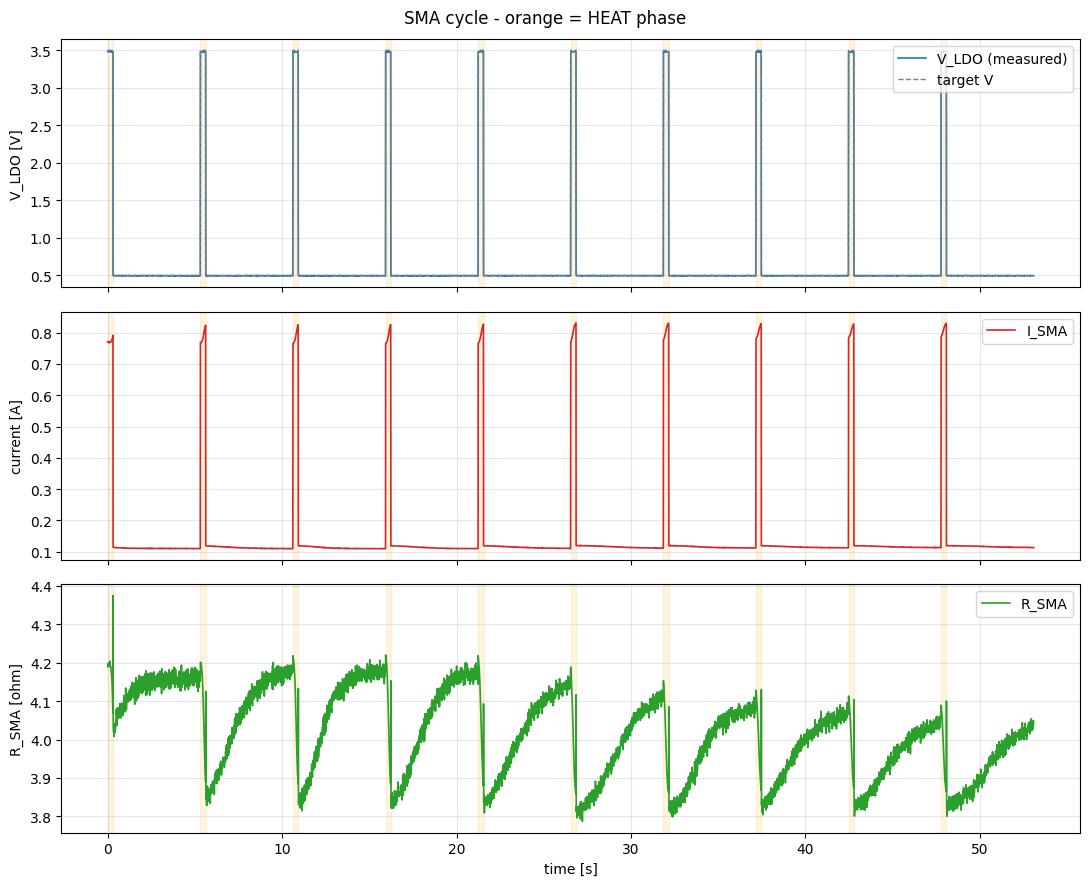

In [23]:
df = load_capture(CYCLE_CSV)
df["t_s"] = df["t_ms"] / 1000.0
if "r_sma_ohm" not in df.columns:   # older logs without the resistance column
    df["r_sma_ohm"] = np.where(df["current_a"] >= 0.005,
                               (df["vldo_v"] - df["current_a"]*RSHUNT) / df["current_a"],
                               np.nan)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

ax1.plot(df["t_s"], df["vldo_v"], color="tab:blue", lw=1.2, label="V_LDO (measured)")
if "target_v" in df:
    ax1.plot(df["t_s"], df["target_v"], color="tab:gray", ls="--", lw=1.0, label="target V")
ax1.set_ylabel("V_LDO [V]"); ax1.legend(loc="upper right"); ax1.grid(alpha=0.3)

ax2.plot(df["t_s"], df["current_a"], color="tab:red", lw=1.2, label="I_SMA")
ax2.set_ylabel("current [A]"); ax2.legend(loc="upper right"); ax2.grid(alpha=0.3)

ax3.plot(df["t_s"], df["r_sma_ohm"], color="tab:green", lw=1.2, label="R_SMA")
ax3.set_ylabel("R_SMA [ohm]"); ax3.set_xlabel("time [s]")
ax3.legend(loc="upper right"); ax3.grid(alpha=0.3)

if "phase" in df:
    in_heat = (df["phase"] == "HEAT").values
    t = df["t_s"].values
    start = None
    for i, h in enumerate(in_heat):
        if h and start is None:
            start = t[i]
        elif not h and start is not None:
            for ax in (ax1, ax2, ax3):
                ax.axvspan(start, t[i], color="orange", alpha=0.12)
            start = None
    if start is not None:
        for ax in (ax1, ax2, ax3):
            ax.axvspan(start, t[-1], color="orange", alpha=0.12)

fig.suptitle("SMA cycle - orange = HEAT phase")
fig.tight_layout(); plt.show()


## Quick stats per phase

In [24]:
if "phase" in df:
    summary = df.groupby("phase").agg(
        n=("t_ms", "size"),
        vldo_mean=("vldo_v", "mean"),
        vldo_max=("vldo_v", "max"),
        current_mean=("current_a", "mean"),
        current_max=("current_a", "max"),
        r_sma_mean=("r_sma_ohm", "mean"),
        r_sma_min=("r_sma_ohm", "min"),
        r_sma_max=("r_sma_ohm", "max"),
    )
    display(summary)


,n,vldo_mean,vldo_max,current_mean,current_max,r_sma_mean,r_sma_min,r_sma_max
phase,,,,,,,,
COOL,5005,0.495453,0.5358,0.114066,0.1199,4.016423,3.787057,4.374126
HEAT,309,3.479626,3.4848,0.796513,0.8308,4.041593,3.857891,4.219699


## Calibration curve: wiper code vs. V_LDO

In [25]:
try:
    cal = load_capture(CAL_CSV)
    plt.figure(figsize=(9, 5))
    plt.plot(cal["code"], cal["vldo_v"], marker=".", ms=4, lw=1, color="tab:green")
    plt.xlabel("wiper code (0-127)"); plt.ylabel("V_LDO [V]")
    plt.title("MCP4018 wiper code -> V_LDO (TPS7A57)")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    print(f"V_LDO range: {cal['vldo_v'].min():.3f} .. {cal['vldo_v'].max():.3f} V")
except FileNotFoundError:
    print(f"No calibration capture at {CAL_CSV} yet. Capture one with:")
    print("  python record_cycle.py --port COM4 --command cal --until '# Calibration complete'")


No calibration capture at logs/cal.csv yet. Capture one with:
  python record_cycle.py --port COM4 --command cal --until '# Calibration complete'
